<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial_13/Tutorial_13_DenoisingAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.66MB/s]



--- Training Deep Denoising Autoencoder ---
Epoch 1/5 | Loss: 0.0655
Epoch 2/5 | Loss: 0.0402
Epoch 3/5 | Loss: 0.0308
Epoch 4/5 | Loss: 0.0271
Epoch 5/5 | Loss: 0.0247

--- Training Variational Autoencoder ---
Epoch 1/5 | Loss: 164.6982
Epoch 2/5 | Loss: 121.2628
Epoch 3/5 | Loss: 114.5370
Epoch 4/5 | Loss: 111.7428
Epoch 5/5 | Loss: 110.0826


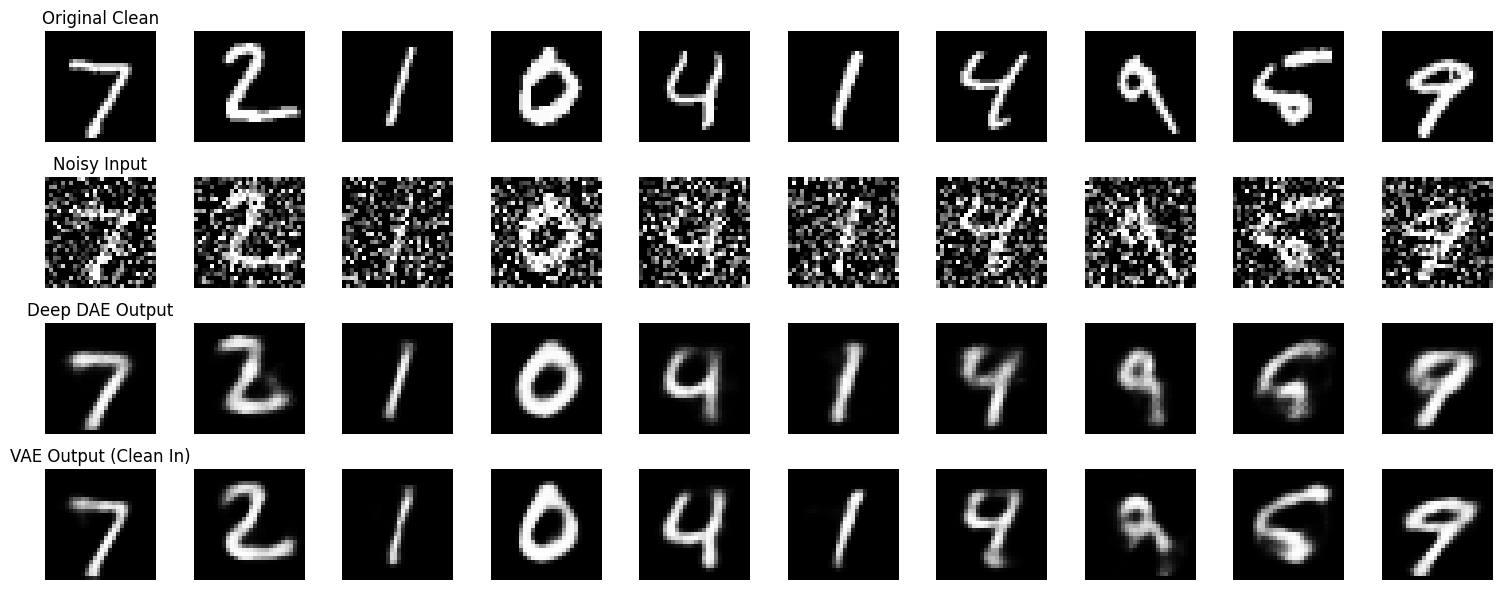

Execution Complete! Results plotted and saved as tutorial_13_results.png


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup & Data Loading ---
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load MNIST Dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=10, shuffle=False)

def add_noise(images, noise_factor=0.5):
    """Injects Gaussian noise into the image tensors."""
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0., 1.)

# --- 2. TASK 1: Deep Denoising Autoencoder ---
class DeepDenoisingAE(nn.Module):
    def __init__(self):
        super(DeepDenoisingAE, self).__init__()
        # Deep Encoder: 784 -> 256 -> 128 -> 64
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU()
        )
        # Deep Decoder: 64 -> 128 -> 256 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 28*28), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(-1, 1, 28, 28)

# --- 3. TASK 2: Variational Autoencoder (VAE) ---
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(28*28, 400) # Encoder
        self.fc21 = nn.Linear(400, 20)   # Latent Mean (mu)
        self.fc22 = nn.Linear(400, 20)   # Latent Log Variance (logvar)
        self.fc3 = nn.Linear(20, 400)    # Decoder start
        self.fc4 = nn.Linear(400, 28*28) # Decoder output

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        x_flat = x.view(-1, 28*28)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        decoded = self.decode(z)
        return decoded.view(-1, 1, 28, 28), mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    """BCE + KL Divergence Loss for VAE"""
    BCE = F.binary_cross_entropy(recon_x.view(-1, 28*28), x.view(-1, 28*28), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# --- 4. Training Functions ---
def train_deep_dae(model, epochs=5):
    print("\n--- Training Deep Denoising Autoencoder ---")
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        train_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            noisy_data = add_noise(data, 0.5)

            optimizer.zero_grad()
            output = model(noisy_data)
            loss = criterion(output, data) # Compare output to CLEAN data
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f}")

def train_vae(model, epochs=5):
    print("\n--- Training Variational Autoencoder ---")
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(epochs):
        train_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            # VAEs are generative, typically trained on clean data
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = vae_loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader.dataset):.4f}")

# --- 5. Execution & Visualization ---
# Initialize models
deep_dae = DeepDenoisingAE().to(device)
vae_model = VAE().to(device)

# Train both models (using 5 epochs for speed in tutorial)
train_deep_dae(deep_dae, epochs=5)
train_vae(vae_model, epochs=5)

# Visualize Results
deep_dae.eval()
vae_model.eval()

# Grab a test batch
dataiter = iter(test_loader)
clean_images, _ = next(dataiter)
clean_images = clean_images.to(device)
noisy_images = add_noise(clean_images, 0.5)

# Get predictions
with torch.no_grad():
    dae_reconstructed = deep_dae(noisy_images)
    vae_reconstructed, _, _ = vae_model(clean_images)

# Plotting
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
clean_np = clean_images.cpu().numpy()
noisy_np = noisy_images.cpu().numpy()
dae_np = dae_reconstructed.cpu().numpy()
vae_np = vae_reconstructed.cpu().numpy()

for i in range(10):
    # Row 1: Original Clean
    axes[0, i].imshow(clean_np[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original Clean")

    # Row 2: Noisy Input (For DAE)
    axes[1, i].imshow(noisy_np[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Noisy Input")

    # Row 3: Deep DAE Output
    axes[2, i].imshow(dae_np[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Deep DAE Output")

    # Row 4: VAE Output
    axes[3, i].imshow(vae_np[i].squeeze(), cmap='gray')
    axes[3, i].axis('off')
    if i == 0: axes[3, i].set_title("VAE Output (Clean In)")

plt.tight_layout()
plt.savefig("tutorial_13_results.png", dpi=300)
plt.show()
print("Execution Complete! Results plotted and saved as tutorial_13_results.png")

1. Generating VAE Latent Space PCA Plot...


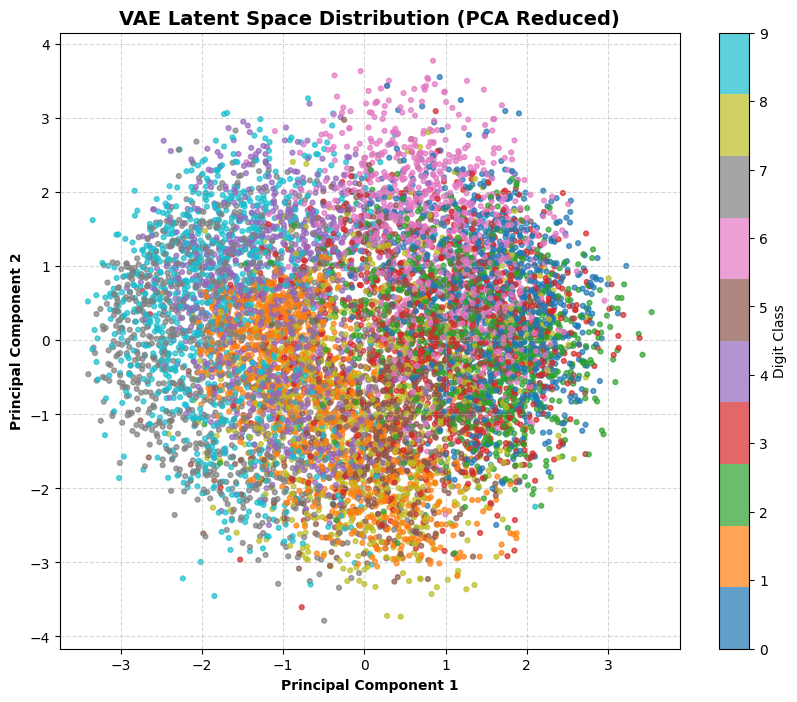

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


2. Generating brand new 'fake' digits from random noise...


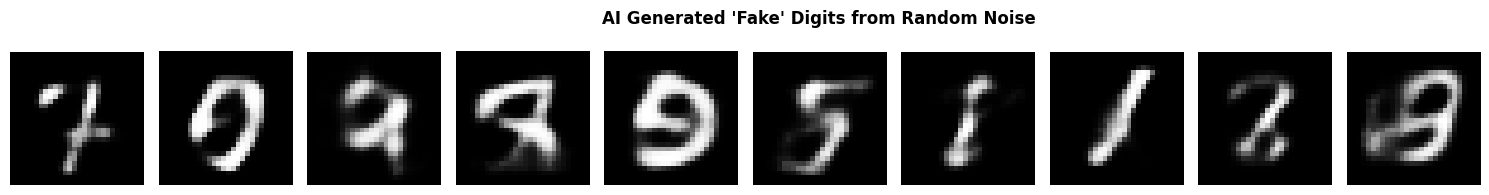

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plots generated and downloaded successfully!


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import torch
from google.colab import files

print("1. Generating VAE Latent Space PCA Plot...")
vae_model.eval()
all_mu = []
all_labels = []

# Extract latent vectors (mu) for the entire test dataset
with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = vae_model.encode(data.view(-1, 28*28))
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

# Reduce the 20-dimensional latent space to 2D for visualization using PCA
pca = PCA(n_components=2)
mu_2d = pca.fit_transform(all_mu)

# Plot the Latent Space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=all_labels, cmap='tab10', alpha=0.7, s=12)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title("VAE Latent Space Distribution (PCA Reduced)", fontweight='bold', fontsize=14)
plt.xlabel("Principal Component 1", fontweight='bold')
plt.ylabel("Principal Component 2", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("vae_latent_space.png", dpi=300, bbox_inches='tight')
plt.show()
files.download("vae_latent_space.png")

print("\n2. Generating brand new 'fake' digits from random noise...")
# A VAE can generate novel images by sampling from a standard normal distribution
with torch.no_grad():
    # Sample 10 random 20-dimensional noise vectors
    random_noise = torch.randn(10, 20).to(device)
    # Decode the noise and IMMEDIATELY reshape it from 784 back to 28x28
    generated_images = vae_model.decode(random_noise).view(-1, 28, 28).cpu().numpy()

# Plot the Generated Digits
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    # Now it is safely 28x28, so imshow will work perfectly
    axes[i].imshow(generated_images[i], cmap='gray')
    axes[i].axis('off')
    if i == 5:
        axes[i].set_title("AI Generated 'Fake' Digits from Random Noise", fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("vae_generated_samples.png", dpi=300, bbox_inches='tight')
plt.show()
files.download("vae_generated_samples.png")

print("Plots generated and downloaded successfully!")